<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 7. Fine-tuning BERT

## Установка, импорт библиотек и базовые настройки

In [1]:
%pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.8 MB/s eta 0:00:00


In [10]:
import os
import random

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    AutoModelForQuestionAnswering,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
    default_data_collator,
)


SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)
if torch.cuda.is_available():
    print("GPU model:", torch.cuda.get_device_name(0))

device: cuda
GPU model: Tesla T4


## Sequence classification

В качестве исходного датасета используется набор данных для классификации новостных текстов на русском ([data-silence/rus_news_classifiera](https://huggingface.co/datasets/data-silence/rus_news_classifier)).

In [3]:
dataset_name = "data-silence/rus_news_classifier"
dataset = load_dataset(dataset_name)

print(dataset)

for split in ["train", "test"]:
    print(f"\n--- {split} examples ---")

    for i in range(3):
        example = dataset[split][i]

        print(
            f"[{i}] sentence = {example["news"]}"
            f"    label    = {example["labels"]}"
        )

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/57530 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14383 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

--- train examples ---
[0] sentence = Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными услугами в квартире на бульваре Яна Райниса. Через некоторое время тело мужчины обнаружили в ванной. Жители дома рассказали полиции, что квартира сдавалась посуточно, и в ней регулярно проходили не только аналогичные сеансы, но и вечеринки, сообщает канал. Точную причину смерти москвича определят следователи. Ранее трое жителей Чечни, чьи личности не раскрываются, пропали после оргии в Грозном. Во время вечеринки компания из четырех человек активно снимала видео, в том числе процесс употребления неизвестного порошка.    label    = 1
[1] sentence = В 2021 год

Ниже представлена токенизация и препроцессинг исходного корпуса.

In [4]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
preprocess = lambda batch: tokenizer(
    batch["news"],
    truncation=True,
    max_length=128,
)

tokenized_dataset = dataset.map(preprocess, batched=True)

tokenized_dataset

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/57530 [00:00<?, ? examples/s]

Map:   0%|          | 0/14383 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14383
    })
})

Загрузка BERT с classification head и вывод модели.

In [5]:
label2id = {
    "climate": 0,
    "conflicts": 1,
    "culture": 2,
    "economy": 3,
    "gloss": 4,
    "health": 5,
    "politics": 6,
    "science": 7,
    "society": 8,
    "sports": 9,
    "travel": 10,
}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Метрики для оценки результата.

In [6]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def calculate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(
        predictions=preds,
        references=labels,
    )["accuracy"]
    f1 = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="weighted",
    )["f1"]

    return {"accuracy": acc, "f1": f1}

Fine-tuning на исходном датасете.

In [7]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

selected_range = range(800)
train_dataset = tokenized_dataset["train"].select(selected_range)
test_dataset = tokenized_dataset["test"].select(selected_range)

steps_per_epoch = len(train_dataset) // 16
eval_steps = 5

print("Приблизительное количество шагов за эпоху:", steps_per_epoch)
print("Валидация каждые", eval_steps, "шагов")

training_args = TrainingArguments(
    output_dir="output",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    logging_strategy="steps",
    logging_steps=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=calculate_metrics,
)

trainer.train()

Приблизительное количество шагов за эпоху: 50
Валидация каждые 5 шагов
{'loss': '2.538', 'grad_norm': '5.208', 'learning_rate': '2e-05', 'epoch': '0.02'}
{'loss': '2.468', 'grad_norm': '7.406', 'learning_rate': '1.98e-05', 'epoch': '0.04'}
{'loss': '2.483', 'grad_norm': '6.89', 'learning_rate': '1.96e-05', 'epoch': '0.06'}
{'loss': '2.345', 'grad_norm': '7.344', 'learning_rate': '1.94e-05', 'epoch': '0.08'}
{'loss': '2.466', 'grad_norm': '5.472', 'learning_rate': '1.92e-05', 'epoch': '0.1'}
{'eval_loss': '2.427', 'eval_accuracy': '0.07125', 'eval_f1': '0.02137', 'eval_runtime': '4.612', 'eval_samples_per_second': '173.5', 'eval_steps_per_second': '5.42', 'epoch': '0.1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.426', 'grad_norm': '5.728', 'learning_rate': '1.9e-05', 'epoch': '0.12'}
{'loss': '2.399', 'grad_norm': '3.505', 'learning_rate': '1.88e-05', 'epoch': '0.14'}
{'loss': '2.412', 'grad_norm': '5.993', 'learning_rate': '1.86e-05', 'epoch': '0.16'}
{'loss': '2.305', 'grad_norm': '4.799', 'learning_rate': '1.84e-05', 'epoch': '0.18'}
{'loss': '2.355', 'grad_norm': '5.259', 'learning_rate': '1.82e-05', 'epoch': '0.2'}
{'eval_loss': '2.409', 'eval_accuracy': '0.1', 'eval_f1': '0.02459', 'eval_runtime': '4.617', 'eval_samples_per_second': '173.3', 'eval_steps_per_second': '5.415', 'epoch': '0.2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.486', 'grad_norm': '3.391', 'learning_rate': '1.8e-05', 'epoch': '0.22'}
{'loss': '2.481', 'grad_norm': '4.104', 'learning_rate': '1.78e-05', 'epoch': '0.24'}
{'loss': '2.326', 'grad_norm': '3.598', 'learning_rate': '1.76e-05', 'epoch': '0.26'}
{'loss': '2.471', 'grad_norm': '4.638', 'learning_rate': '1.74e-05', 'epoch': '0.28'}
{'loss': '2.46', 'grad_norm': '3.682', 'learning_rate': '1.72e-05', 'epoch': '0.3'}
{'eval_loss': '2.407', 'eval_accuracy': '0.0975', 'eval_f1': '0.0174', 'eval_runtime': '5.888', 'eval_samples_per_second': '135.9', 'eval_steps_per_second': '4.246', 'epoch': '0.3'}


...

{'loss': '2.41', 'grad_norm': '4.753', 'learning_rate': '1e-06', 'epoch': '1.92'}
{'loss': '2.34', 'grad_norm': '5.169', 'learning_rate': '8e-07', 'epoch': '1.94'}
{'loss': '2.336', 'grad_norm': '2.996', 'learning_rate': '6e-07', 'epoch': '1.96'}
{'loss': '2.408', 'grad_norm': '3.435', 'learning_rate': '4e-07', 'epoch': '1.98'}
{'loss': '2.401', 'grad_norm': '3.968', 'learning_rate': '2e-07', 'epoch': '2'}
{'eval_loss': '2.372', 'eval_accuracy': '0.1437', 'eval_f1': '0.04594', 'eval_runtime': '5.059', 'eval_samples_per_second': '158.2', 'eval_steps_per_second': '4.942', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '557.8', 'train_samples_per_second': '2.868', 'train_steps_per_second': '0.179', 'train_loss': '2.386', 'epoch': '2'}


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=100, training_loss=2.386303358078003, metrics={'train_runtime': 557.8107, 'train_samples_per_second': 2.868, 'train_steps_per_second': 0.179, 'train_loss': 2.386303358078003, 'epoch': 2.0})

Оценка на тестовой выборке.

In [8]:
metrics = trainer.evaluate()
metrics

{'eval_loss': '2.371', 'eval_accuracy': '0.1462', 'eval_f1': '0.05171', 'eval_runtime': '5.136', 'eval_samples_per_second': '155.8', 'eval_steps_per_second': '4.868', 'epoch': '2'}


{'eval_loss': 2.370600700378418,
 'eval_accuracy': 0.14625,
 'eval_f1': 0.05170660799874283,
 'eval_runtime': 5.1361,
 'eval_samples_per_second': 155.76,
 'eval_steps_per_second': 4.868,
 'epoch': 2.0}

Отфильтрованные логи и графики.

=== Train Logs ===


,step,epoch,loss,grad_norm,learning_rate
108,91,1.82,2.308842,5.346197,2.000000e-06
109,92,1.84,2.400767,5.487062,1.800000e-06
110,93,1.86,2.506062,3.995981,1.600000e-06
111,94,1.88,2.352669,4.159368,1.400000e-06
112,95,1.90,2.367158,4.838870,1.200000e-06
114,96,1.92,2.409707,4.753381,1.000000e-06
115,97,1.94,2.340034,5.168581,8.000000e-07
116,98,1.96,2.335639,2.995879,6.000000e-07
117,99,1.98,2.408487,3.435231,4.000000e-07
118,100,2.00,2.400817,3.968235,2.000000e-07



=== Eval Logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1,eval_runtime
71,60,1.2,2.377566,0.13500,0.044826,5.0662
77,65,1.3,2.379331,0.13250,0.042383,5.0648
83,70,1.4,2.390973,0.11750,0.047130,5.0541
89,75,1.5,2.381368,0.12500,0.050909,5.1019
95,80,1.6,2.368623,0.14375,0.044074,5.0678
101,85,1.7,2.370588,0.14625,0.051707,5.1427
107,90,1.8,2.372616,0.14500,0.048209,5.0717
113,95,1.9,2.371189,0.14500,0.046410,5.1279
119,100,2.0,2.371880,0.14375,0.045942,5.0585
121,100,2.0,2.370601,0.14625,0.051707,5.1361



=== Summary Logs ===


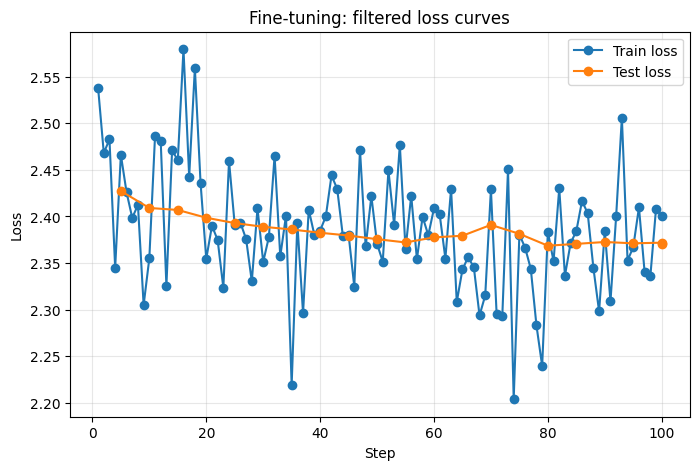

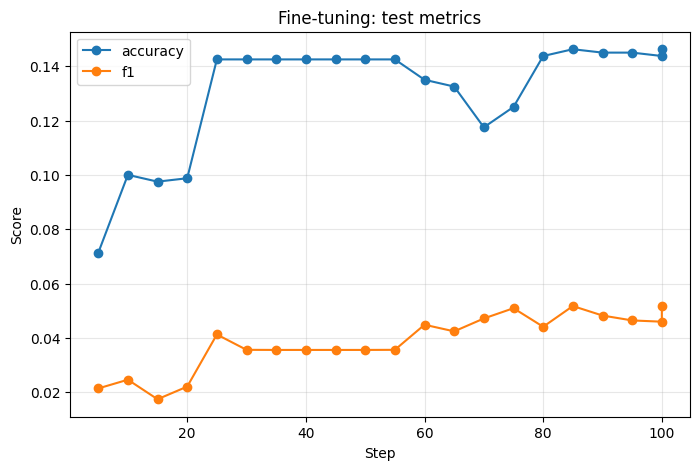

In [9]:
log_df = pd.DataFrame(trainer.state.log_history)

train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
test_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train Logs ===")
if len(train_logs) > 0:
    cols = [
        c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"]
        if c in train_logs.columns
    ]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval Logs ===")
if len(test_logs) > 0:
    cols = [
        c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_runtime"]
        if c in test_logs.columns
    ]
    display(test_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Summary Logs ===")
if len(summary_logs) > 0:
    cols = [
        c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"]
        if c in summary_logs.columns
    ]
else:
    print("Нет summary-логов")

plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Train loss")

if len(test_logs) > 0:
    plt.plot(test_logs["step"], test_logs["eval_loss"], marker="o", label="Test loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

metric_cols = [
    c for c in ["eval_accuracy", "eval_f1"]
    if c in test_logs.columns
]

if len(test_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))

    for col in metric_cols:
        plt.plot(
            test_logs["step"],
            test_logs[col],
            marker="o",
            label=col.replace("eval_", ""),
        )

    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("Fine-tuning: test metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет test-метрик для построения графика")

Предсказания модели.

In [10]:
sample_texts = [
    "В Перми скончался 82-летний актер театра и кино Всевлод Авсентьев",
    "Чемпионат мира по футболу закончился победой Румынии",
    "В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров.",
]
inputs = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
    return_tensors="pt",
).to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()

for text, pred in zip(sample_texts, preds):
    print(f"TEXT: {text}")
    print(f"PRED: {id2label[int(pred)]}")
    print()

TEXT: В Перми скончался 82-летний актер театра и кино Всевлод Авсентьев
PRED: gloss

TEXT: Чемпионат мира по футболу закончился победой Румынии
PRED: gloss

TEXT: В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров.
PRED: gloss



## Token classification / NER

Для этого задания используется датасет [unimelb-nlp/wikiann](https://huggingface.co/datasets/unimelb-nlp/wikiann).

In [15]:
dataset = load_dataset("unimelb-nlp/wikiann", "ru")
print(dataset)

labels = dataset["train"].features["ner_tags"].feature.names
print("NER labels:", labels)

for i in range(2):
    ex = dataset["train"][i]
    print(f"\n--- example {i}")
    print("tokens:", ex["tokens"])
    print("tags:  ", [labels[t] for t in ex["ner_tags"]])

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})
NER labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

--- example 0
tokens: ['Илизаров', ',', 'Гавриил', 'Абрамович']
tags:   ['B-PER', 'I-PER', 'I-PER', 'I-PER']

--- example 1
tokens: ["'", "''", 'Рыбницкий', 'район', "''", "'"]
tags:   ['O', 'O', 'B-LOC', 'I-LOC', 'O', 'O']


Токенизатор и выравнивание NER-меток по subwords.

In [16]:
ner_checkpoint = "bert-base-cased"
ner_tokenizer = AutoTokenizer.from_pretrained(ner_checkpoint)


def tokenize_and_align_labels(examples):
    tokenized = ner_tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )

    aligned_labels = []

    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)

            previous_word_id = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels

    return tokenized


ner_tokenized = dataset.map(tokenize_and_align_labels, batched=True)
print(ner_tokenized)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
})


Загрузка BERT с token classification head и печать модели.

In [18]:
num_labels = len(labels)

model = AutoModelForTokenClassification.from_pretrained(
    ner_checkpoint,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(labels)},
    label2id={name: i for i, name in enumerate(labels)},
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized beca

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

Метрики для NER.

In [22]:
label_names = [model.config.id2label[i] for i in range(len(model.config.id2label))]


def compute_metrics_ner(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        cur_preds = []
        cur_labels = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                cur_preds.append(label_names[p])   # map id -> string
                cur_labels.append(label_names[l])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    metrics = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": metrics["overall_precision"],
        "recall":    metrics["overall_recall"],
        "f1":        metrics["overall_f1"],
        "accuracy":  metrics["overall_accuracy"],
    }

Fine-tuning на исходном датасете.

In [23]:
ner_data_collator = DataCollatorForTokenClassification(tokenizer=ner_tokenizer)
ner_training_args = TrainingArguments(
    output_dir="./bert-wiki",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)
ner_trainer = Trainer(
    model=model,
    args=ner_training_args,
    train_dataset=ner_tokenized["train"],
    eval_dataset=ner_tokenized["validation"],
    processing_class=ner_tokenizer,
    data_collator=ner_data_collator,
    compute_metrics=compute_metrics_ner,
)

ner_trainer.train()

{'loss': '0.3146', 'grad_norm': '4.291', 'learning_rate': '1.961e-05', 'epoch': '0.04'}
{'loss': '0.2589', 'grad_norm': '4.939', 'learning_rate': '1.921e-05', 'epoch': '0.08'}
{'loss': '0.2381', 'grad_norm': '7.243', 'learning_rate': '1.881e-05', 'epoch': '0.12'}
{'loss': '0.2278', 'grad_norm': '5.842', 'learning_rate': '1.841e-05', 'epoch': '0.16'}
{'loss': '0.2318', 'grad_norm': '3.871', 'learning_rate': '1.801e-05', 'epoch': '0.2'}
{'loss': '0.2249', 'grad_norm': '3.639', 'learning_rate': '1.761e-05', 'epoch': '0.24'}
{'loss': '0.2036', 'grad_norm': '10.5', 'learning_rate': '1.721e-05', 'epoch': '0.28'}
{'loss': '0.2164', 'grad_norm': '4.85', 'learning_rate': '1.681e-05', 'epoch': '0.32'}
{'loss': '0.2019', 'grad_norm': '3.338', 'learning_rate': '1.641e-05', 'epoch': '0.36'}
{'loss': '0.2243', 'grad_norm': '6.617', 'learning_rate': '1.601e-05', 'epoch': '0.4'}
{'loss': '0.2401', 'grad_norm': '6.487', 'learning_rate': '1.561e-05', 'epoch': '0.44'}
{'loss': '0.1647', 'grad_norm': '4.0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1784', 'grad_norm': '11.77', 'learning_rate': '9.608e-06', 'epoch': '1.04'}
{'loss': '0.1804', 'grad_norm': '8.216', 'learning_rate': '9.208e-06', 'epoch': '1.08'}
{'loss': '0.1816', 'grad_norm': '6.365', 'learning_rate': '8.808e-06', 'epoch': '1.12'}
{'loss': '0.2023', 'grad_norm': '7.164', 'learning_rate': '8.408e-06', 'epoch': '1.16'}
{'loss': '0.1567', 'grad_norm': '7.284', 'learning_rate': '8.008e-06', 'epoch': '1.2'}
{'loss': '0.2206', 'grad_norm': '7.494', 'learning_rate': '7.608e-06', 'epoch': '1.24'}
{'loss': '0.2003', 'grad_norm': '5.724', 'learning_rate': '7.208e-06', 'epoch': '1.28'}
{'loss': '0.173', 'grad_norm': '5.005', 'learning_rate': '6.808e-06', 'epoch': '1.32'}
{'loss': '0.1772', 'grad_norm': '4.372', 'learning_rate': '6.408e-06', 'epoch': '1.36'}
{'loss': '0.1988', 'grad_norm': '14.47', 'learning_rate': '6.008e-06', 'epoch': '1.4'}
{'loss': '0.1835', 'grad_norm': '6.835', 'learning_rate': '5.608e-06', 'epoch': '1.44'}
{'loss': '0.1746', 'grad_norm': '2.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '908.4', 'train_samples_per_second': '44.03', 'train_steps_per_second': '2.752', 'train_loss': '0.1883', 'epoch': '2'}


TrainOutput(global_step=2500, training_loss=0.18833396186828613, metrics={'train_runtime': 908.3816, 'train_samples_per_second': 44.034, 'train_steps_per_second': 2.752, 'train_loss': 0.18833396186828613, 'epoch': 2.0})

Оценка на validation.

In [24]:
ner_metrics = ner_trainer.evaluate()
ner_metrics

{'eval_loss': '0.2361', 'eval_precision': '0.795', 'eval_recall': '0.8276', 'eval_f1': '0.811', 'eval_accuracy': '0.933', 'eval_runtime': '57.99', 'eval_samples_per_second': '172.4', 'eval_steps_per_second': '5.397', 'epoch': '2'}


{'eval_loss': 0.23606005311012268,
 'eval_precision': 0.7949659970296256,
 'eval_recall': 0.82763671875,
 'eval_f1': 0.8109724492643834,
 'eval_accuracy': 0.9330035842293907,
 'eval_runtime': 57.9912,
 'eval_samples_per_second': 172.44,
 'eval_steps_per_second': 5.397,
 'epoch': 2.0}

Несколько предсказаний NER.

In [25]:
example = dataset["validation"][0]
tokens = example["tokens"]

inputs = ner_tokenizer(
    tokens,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
).to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    pred_ids = outputs.logits.argmax(dim=-1)[0].cpu().tolist()

word_ids = inputs.word_ids(batch_index=0)

predicted_labels = []
seen = set()

for token_idx, word_id in enumerate(word_ids):
    if word_id is None or word_id in seen:
        continue

    seen.add(word_id)
    predicted_labels.append((tokens[word_id], label_names[pred_ids[token_idx]]))

print("Token -> predicted label")
for token, label in predicted_labels:
    print(f"{token:15s} {label}")

Token -> predicted label
Отличился       O
во              O
время           O
боёв            O
в               O
Германии        B-LOC
.               O


Вопросы для самопроверки:

1. Почему для классификации текста удобно использовать `[CLS]`-представление?  
Токен `[CLS]` специально добавляется в начало каждой последовательности при обучении BERT. За счёт механизма self-attention его итоговое скрытое состояние «видит» все остальные токены и агрегирует информацию о всём предложении — то есть получается вектор фиксированной длины, описывающий весь вход целиком. Это удобно для классификации: вместо того чтобы как-то усреднять или пулить представления всех токенов, мы берём один вектор `[CLS]`, подаём его в линейный слой-классификатор и получаем логиты по классам. К тому же во время предобучения (в задаче NSP у оригинального BERT) `[CLS]` уже учился представлять предложение целиком, так что это естественная «точка входа» для downstream-классификации.
2. Чем отличаются `AutoModelForSequenceClassification` и `AutoModelForTokenClassification`?  
Оба класса — это обёртки над одним и тем же базовым трансформером, но с разными «головами» сверху и разной формой выхода:

   - `AutoModelForSequenceClassification` решает задачу «одна метка на всю последовательность» (sentiment analysis, NLI, классификация тем и т.д.). Голова берёт представление `[CLS]` (точнее — pooled output) и проецирует его в вектор размерности `num_labels`. Логиты имеют форму `(batch_size, num_labels)`. Лейблы при обучении — один int на пример;
   - `AutoModelForTokenClassification` решает задачу «метка на каждый токен» (NER, POS-теггинг, chunking). Голова применяется к скрытым состояниям всех токенов, а не только `[CLS]`. Логиты имеют форму `(batch_size, seq_len, num_labels)`. Лейблы — последовательность той же длины, что и вход, по одной метке на токен;  
   
    То есть разница не в backbone, а в том, к чему прикладывается классификационный слой и какой размерности получается выход.
3. Зачем в NER мы используем `-100`?  
`-100` — это специальное значение, которое по умолчанию игнорирует `CrossEntropyLoss` в PyTorch (параметр `ignore_index=-100`). В NER оно нужно из-за несоответствия между «словами» и «субтокенами»:

    - Разметка NER даётся на уровне слов, а BERT-токенизатор режет слова на sub-word pieces (например, `Washington → Wash`, `##ington`);
    - Для первого субтокена слова мы ставим настоящую метку (`B-LOC`), а для всех последующих субтокенов того же слова — `-100`, чтобы они не участвовали в подсчёте лосса и метрик;
    - Аналогично `-100` ставится для служебных токенов: `[CLS]`, `[SEP]`, `[PAD]`.

    Благодаря этому модель обучается предсказывать метку только один раз на слово, и паддинги/служебные токены не искажают градиенты и метрики. Именно поэтому в `compute_metrics` нужно вручную отфильтровать все позиции с `l == -100` перед передачей в `seqeval` — иначе метрика увидит «мусорные» позиции.

4. Почему для NER часто лучше `bert-base-cased`?  
Потому что для распознавания именованных сущностей регистр букв — это сильнейший признак. В английском с заглавной буквы пишутся именно имена людей, названия организаций, географические объекты и т.п. Сравните: `apple` (фрукт) vs `Apple` (компания), `bush` (куст) vs `Bush` (фамилия):  
    - `bert-base-uncased` приводит всё к нижнему регистру ещё на этапе токенизации — эта информация теряется **безвозвратно**, и модель физически не может её использовать.
    - `bert-base-cased` сохраняет регистр, и модель учится использовать заглавные буквы как очень полезный сигнал для границ и типов сущностей.

    На классических NER-бенчмарках (CoNLL-2003) cased-версия стабильно даёт выше F1, чем uncased, примерно на 1–2 пункта. Для задач вроде sentiment analysis разница обычно незначительна или даже в пользу uncased, а вот для NER cased — почти всегда правильный выбор.

5. Что меняется, если взять другой датасет, но ту же задачу?  
Если задача остаётся та же (например, NER), большая часть пайплайна переиспользуется без изменений: архитектура модели, функция выравнивания меток с субтокенами, обработка `-100`, `compute_metrics` на основе `seqeval`, `DataCollatorForTokenClassification`, цикл обучения. Меняется в основном следующее:  
    - Набор меток и их количество. У CoNLL-2003 — 9 меток (`O`, `B-PER`, `I-PER`, `B-ORG`, …), у OntoNotes — 37, у биомедицинских датасетов вроде BC5CDR — свои (`B-Chemical`, `B-Disease`). Значит, нужно заново построить `label2id` / `id2label` и пересоздать модель с правильным `num_labels` — старую голову классификатора переиспользовать нельзя, backbone же переиспользуется;
    - Схема разметки. Где-то IOB2 (`B-`/`I-`/`O`), где-то BIOES/IOBES с дополнительными `E-` и `S-`. `seqeval` это поддерживает, но надо следить за согласованностью;
    - Формат самих данных. Поля могут называться по-разному (`tokens` / `words`, `ner_tags` / `labels` / `tags`), разметка может быть на уровне слов или уже на уровне символов (тогда нужна конвертация в BIO);
    - Домен и язык. Для биомедицины лучше взять `BioBERT` или `PubMedBERT`, для юридических текстов — `LegalBERT`, для русского — `rubert-base-cased` или мультиязычную модель. Общий `bert-base-cased` на узкоспециальной лексике будет работать заметно хуже;
    - Гиперпараметры. Число эпох, learning rate, размер батча и max_length стоит подбирать под размер и длину примеров нового датасета;
    - Метрики остаются теми же (precision/recall/F1 на уровне сущностей через `seqeval`), но абсолютные значения несравнимы между датасетами — CoNLL «лёгкий», биомед и соцсети — заметно сложнее.

## Sentence Pair Classification

Для задачи SPC использован датасет glue.

In [3]:
dataset = load_dataset("glue", "qnli")
print(dataset)

for split in ["train", "validation"]:
    print(f"\n--- {split} examples ---")

    for i in range(2):
        ex = dataset[split][i]
        print(f"[{i}] question = {ex["question"]}")
        print(f"    sentence = {ex["sentence"]}")
        print(f"    label    = {ex["label"]}")
        print()

README.md: 0.00B [00:00, ?B/s]

qnli/train-00000-of-00001.parquet:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

qnli/validation-00000-of-00001.parquet:   0%|          | 0.00/872k [00:00<?, ?B/s]

qnli/test-00000-of-00001.parquet:   0%|          | 0.00/877k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/104743 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5463 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5463 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

--- train examples ---
[0] question = When did the third Digimon series begin?
    sentence = Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.
    label    = 1

[1] question = Which missile batteries often have individual launchers several kilometres from one another?
    sentence = When MANPADS is operated by specialists, batteries may have several dozen teams deploying separately in small sections; self-propelled air d

Токенизация пар предложений.

In [4]:
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def preprocess_pair(batch):
    return tokenizer(
        batch["question"],
        batch["sentence"],
        truncation=True,
        max_length=256,
    )


train_small = dataset["train"].select(range(3000))
val_small = dataset["validation"].select(range(500))

train_tok = train_small.map(preprocess_pair, batched=True)
val_tok = val_small.map(preprocess_pair, batched=True)
print(train_tok)
print(val_tok)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/104743 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})


Загрузка BERT с головой для SPC.

In [5]:
id2label = {
    idx: label
    for idx, label in enumerate(dataset["train"].features["label"].names)
}
label2id = {label: idx for idx, label in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Метрики и fine-tuning.

In [7]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")


def compute_metrics_pair(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(
        predictions=preds,
        references=labels,
    )["accuracy"]
    f1_metric = f1.compute(
        predictions=preds,
        references=labels,
        average="binary",
    )["f1"]

    return {"accuracy": acc, "f1": f1_metric}


collator = DataCollatorWithPadding(tokenizer=tokenizer)
args = TrainingArguments(
    output_dir="./bert-mrpc",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics_pair,
)

trainer.train()
metrics = trainer.evaluate()
metrics

{'loss': '0.2539', 'grad_norm': '6.271', 'learning_rate': '1.993e-05', 'epoch': '0.007637'}
{'loss': '0.2537', 'grad_norm': '11.2', 'learning_rate': '1.985e-05', 'epoch': '0.01527'}
{'loss': '0.2848', 'grad_norm': '7.316', 'learning_rate': '1.977e-05', 'epoch': '0.02291'}
{'loss': '0.2386', 'grad_norm': '18.32', 'learning_rate': '1.97e-05', 'epoch': '0.03055'}
{'loss': '0.2252', 'grad_norm': '5.901', 'learning_rate': '1.962e-05', 'epoch': '0.03819'}
{'loss': '0.2361', 'grad_norm': '5.613', 'learning_rate': '1.954e-05', 'epoch': '0.04582'}
{'loss': '0.2271', 'grad_norm': '4.949', 'learning_rate': '1.947e-05', 'epoch': '0.05346'}
{'loss': '0.2291', 'grad_norm': '6.18', 'learning_rate': '1.939e-05', 'epoch': '0.0611'}
{'loss': '0.2433', 'grad_norm': '4.353', 'learning_rate': '1.931e-05', 'epoch': '0.06873'}
{'loss': '0.24', 'grad_norm': '9.825', 'learning_rate': '1.924e-05', 'epoch': '0.07637'}
{'loss': '0.1942', 'grad_norm': '8.882', 'learning_rate': '1.916e-05', 'epoch': '0.08401'}
{'lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2055', 'grad_norm': '1.544', 'learning_rate': '9.997e-06', 'epoch': '1'}
{'loss': '0.1612', 'grad_norm': '6.188', 'learning_rate': '9.921e-06', 'epoch': '1.008'}
{'loss': '0.1702', 'grad_norm': '6.824', 'learning_rate': '9.844e-06', 'epoch': '1.016'}
{'loss': '0.1608', 'grad_norm': '0.4215', 'learning_rate': '9.768e-06', 'epoch': '1.023'}
{'loss': '0.2286', 'grad_norm': '0.2801', 'learning_rate': '9.691e-06', 'epoch': '1.031'}
{'loss': '0.1608', 'grad_norm': '10.88', 'learning_rate': '9.615e-06', 'epoch': '1.039'}
{'loss': '0.1536', 'grad_norm': '30.75', 'learning_rate': '9.539e-06', 'epoch': '1.046'}
{'loss': '0.1826', 'grad_norm': '3.336', 'learning_rate': '9.462e-06', 'epoch': '1.054'}
{'loss': '0.1132', 'grad_norm': '62.24', 'learning_rate': '9.386e-06', 'epoch': '1.062'}
{'loss': '0.1588', 'grad_norm': '44.71', 'learning_rate': '9.31e-06', 'epoch': '1.069'}
{'loss': '0.1356', 'grad_norm': '1.106', 'learning_rate': '9.233e-06', 'epoch': '1.077'}
{'loss': '0.1669', 'grad

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '3868', 'train_samples_per_second': '54.16', 'train_steps_per_second': '3.385', 'train_loss': '0.1548', 'epoch': '2'}
{'eval_loss': '0.3718', 'eval_accuracy': '0.912', 'eval_f1': '0.9122', 'eval_runtime': '38.95', 'eval_samples_per_second': '140.3', 'eval_steps_per_second': '4.39', 'epoch': '2'}


{'eval_loss': 0.3717834949493408,
 'eval_accuracy': 0.9119531393007505,
 'eval_f1': 0.9122422915526364,
 'eval_runtime': 38.9484,
 'eval_samples_per_second': 140.262,
 'eval_steps_per_second': 4.39,
 'epoch': 2.0}

Предсказания для SPC.

In [9]:
i, j = 1337, 228
examples = [
    (dataset["test"][i]["question"], dataset["test"][i]["sentence"]),
    (dataset["test"][j]["question"], dataset["test"][j]["sentence"]),
]

enc = tokenizer(
    [x[0] for x in examples],
    [x[1] for x in examples],
    truncation=True,
    padding=True,
    return_tensors="pt",
).to(model.device)

with torch.no_grad():
    logits = model(**enc).logits
    preds = logits.argmax(dim=-1).cpu().tolist()

for (question, sentence), pred in zip(examples, preds):
    print("QUESTION:", question)
    print("SENTENCE:", sentence)
    print("PRED    :", id2label[pred])

QUESTION: Which examples of fashion does the museum continue to acquire for its collection?
SENTENCE: In 2002, the Museum acquired the Costiff collection of 178 Vivienne Westwood costumes.
PRED    : entailment
QUESTION: What type of compounds such as acetone,contain oxygen?
SENTENCE: Other important organic compounds that contain oxygen are: glycerol, formaldehyde, glutaraldehyde, citric acid, acetic anhydride, and acetamide.
PRED    : not_entailment


## Extractive Question Answering

Для данного задания используется датасет squad_v2.

In [11]:
dataset = load_dataset("squad_v2")
print(dataset)

for i in range(2):
    example = dataset["train"][i]
    print(f"\n--- example {i} ---")
    print("question:", example["question"])
    print("context :", example["context"][:400], "...")
    print("answers :", example["answers"])

README.md: 0.00B [00:00, ?B/s]

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})

--- example 0 ---
question: When did Beyonce start becoming popular?
context : Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child. Managed by her father, Mathew Knowles, the group became one of  ...
answers : {'text': ['in the late 1990s'], 'answer_start': [269]}

--- example 1 ---
question: What areas did Beyonce compete in when she was growing up?
context : Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is a

Токенизация и построение начальных и конечных позиций.

In [ ]:
checkpoint = "best-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
max_length = 384
doc_stride = 128


def preprocess_qa_train(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )
    offset_mapping = inputs["offset_mapping"]
    sample_map = inputs["overflow_to_sample_mapping"]

    start_positions = []
    end_positinons = []

    for i, offsets in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answer = examples["answers"][sample_idx]
        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = inputs.sequence_ids(i)
        context_start = 0

        while sequence_ids[context_start] != 1:
            context_start += 1

        context_end = len(sequence_ids) - 1

        while sequence_ids[context_end] != 1:
            context_end -= 1

        if (
            offsets[context_start][0] > end_char or
            offsets[context_end][1] < start_char
        ):
            start_positions.append(0)
            end_positions.append(0)
        else:
            token_start = context_start

            while (
                token_start <= context_end and
                offsets[token_start][0] < start_char
            ):
                token_start += 1

            start_positions.append(token_start - 1)

            while (
                token_end >= context_start and
                offsets[token_end][1] >= end_char
            ):
                token_end -= 1

            end_positions.append(token_end + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs


train_small = dataset["train"].select(range(3000))
val_small = dataset["validation"].select(range(500))

train_tok = train_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=train_small.column_names,
)
val_tok = val_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=val_small.column_names,
)

print(train_tok)
print(val_tok)

Загрузка BERT с QA Head и печать модели.

In [ ]:
model = AutoModelForQuestionAnswering.from_pretrained(checkpoint)

print(model)
print("\nQA outputs head:")
print(model.qa_outputs)

Fine-tuning на небольшом подмножестве.

In [ ]:
args = TrainingArguments(
    output_dir="./bert_squad",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=default_data_collator,
)

trainer.train()
eval = trainer.evaluate()
eval

Пример инференса.

In [ ]:
example = dataset["validation"][0]
question = example["question"]
context = example["context"]
inputs = tokenizer(
    question,
    context,
    return_tensors="pt",
    truncation=True,
    max_length=384,
).to(model.device)

with torch.no_grad():
    outputs = model(**inputs)

start_idx = int(outputs.start_logits.argmax(dim=-1)[0])
end_idx = int(outputs.end_logits.argmax(dim=-1)[0])

tokens = inputs["input_ids"][0]
pred_answer = tokenizer.decode(
    tokens[start_idx:end_idx + 1],
    skip_special_tokens=True,
)

print("QUESTION         :", question)
print("PREDICATED ANSWER:", pred_answer)
print("GOLD ANSWERS     :", example["answers"]["text"])

Контрольные вопросы:

1. Почему extractive QA требует start/end logits  
В extractive QA ответ — это непрерывный фрагмент (span) исходного контекста, а не сгенерированный текст и не метка класса. Чтобы указать такой фрагмент, модели достаточно предсказать две вещи: где он начинается и где он заканчивается. Именно это и делают start/end logits — для каждого токена входа модель выдаёт два числа: «насколько вероятно, что ответ начинается на этом токене» и «насколько вероятно, что он здесь заканчивается».

    Дальше применяется softmax по длине последовательности отдельно для start и для end, и ответом считается пара `(i, j)` (где `i ≤ j` и обычно `j − i < max_answer_length`), максимизирующая сумму `start_logit[i] + end_logit[j]`. Два логита нужны именно потому, что span задаётся **двумя границами** — одного числа на токен было бы недостаточно, чтобы однозначно описать отрезок произвольной длины.

    Отдельно стоит упомянуть «нет ответа» (SQuAD 2.0, MuSeRC-подобные задачи): обычно это кодируется как span `(0, 0)`, указывающий на токен `[CLS]` — то есть модель тем же механизмом сообщает, что ответа в контексте нет.

2. Чем QA head отличается от обычной классификации  
У классификационной головы (как в MRPC, QNLI, MuSeRC) логиты считаются один раз на всю последовательность — обычно поверх эмбеддинга `[CLS]` (или pooled output). Размерность выхода — `[batch, num_labels]`, и задача сводится к выбору одного класса из фиксированного множества.

    У QA-головы логиты считаются для каждого токена входа, причём сразу в двух «каналах» — start и end. Размерность выхода — `[batch, seq_len, 2]` (или два тензора `[batch, seq_len]`). Технически это просто линейный слой `hidden_size → 2`, применённый к выходам всех токенов, а не только к `[CLS]`. Ключевые отличия:

    - На что смотрим: классификация — на один агрегированный вектор; QA — на последовательность токенов.
    - Пространство ответов: у классификации оно фиксировано (`num_labels` заранее известно); у QA оно зависит от длины входа — ответом может быть любой из `O(seq_len²)` возможных спанов.
    - Loss: в классификации — одна cross-entropy по меткам классов; в QA — две cross-entropy (по позиции начала и по позиции конца), которые усредняются.
    - Постобработка: у классификации — `argmax` по логитам. У QA нужен отдельный шаг: перебрать top-k пар `(start, end)`, отфильтровать невалидные (end < start, span вне контекста, слишком длинный), спроецировать индексы токенов обратно в символы исходного текста через `offset_mapping`.
    
3. Почему для длинных контекстов нужен `stride`  
Трансформеры-энкодеры имеют жёсткий лимит на длину входа (обычно 512 токенов у BERT-подобных моделей). Контекст в extractive QA часто длиннее — целый абзац из Википедии, документ, параграф MuSeRC. Простое обрезание (`truncation=True`) решает проблему длины, но выбрасывает часть текста, и если правильный ответ оказался в отрезанном куске, модель его физически не увидит и никогда не сможет предсказать.

    Решение — скользящее окно с перекрытием. Длинный контекст разбивается на несколько перекрывающихся «фич», каждая из которых помещается в лимит модели. `stride` задаёт размер перекрытия между соседними окнами (в токенах). В `transformers` это включается так:

    ```python
    tokenizer(
        question, context,
        truncation="only_second",       # режем только контекст, вопрос оставляем целиком
        max_length=384,
        stride=128,                      # соседние окна перекрываются на 128 токенов
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
    )
    ```

    Зачем именно перекрытие, а не просто нарезка встык: если ответ расположен на границе между двумя окнами, то при нарезке встык он окажется разорван — начало в одном окне, конец в другом — и ни одно из окон не будет содержать полный span. Перекрытие в `stride` токенов гарантирует, что любой ответ короче `stride` целиком поместится хотя бы в одно окно.

    На инференсе модель прогоняется по всем окнам одного примера, логиты собираются вместе, и финальный ответ выбирается как лучший span по всем окнам сразу — с учётом того, какие токены в каждом окне относятся к контексту (а не к вопросу или спецтокенам), это отслеживается через `sequence_ids` и `offset_mapping`.ллоло